<a href="https://colab.research.google.com/github/JiyaJibu/Multimodal_Project/blob/main/Mutltimodal_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import shutil

# Remove the existing drive folder completely
if os.path.exists('/content/drive'):
    shutil.rmtree('/content/drive')

# Recreate empty directory
os.makedirs('/content/drive', exist_ok=True)

print("✅ Clean mountpoint ready")

✅ Clean mountpoint ready


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf
import keras

print("TensorFlow Version:", tf.__version__)
print("Keras Version:", keras.__version__)


TensorFlow Version: 2.20.0
Keras Version: 3.13.2


In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import os
BASE_PATH = "/content/drive/MyDrive/Multimodal_Project"
os.makedirs(BASE_PATH, exist_ok=True)

print("Project folder created at:", BASE_PATH)


Project folder created at: /content/drive/MyDrive/Multimodal_Project


In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/Multimodal_Project/raw_data/LivDet2015.zip"

# Folder where files will be extracted
extract_path = "/content/drive/MyDrive/Multimodal_Project/raw_data/LivDet2015"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Extraction complete")


✅ Extraction complete


In [ ]:
import os

for root, dirs, files in os.walk(extract_path):
    print(root, "→", len(files))


/content/drive/MyDrive/Multimodal_Project/raw_data/LivDet2015 → 0
/content/drive/MyDrive/Multimodal_Project/raw_data/LivDet2015/LivDet2015 → 0
/content/drive/MyDrive/Multimodal_Project/raw_data/LivDet2015/LivDet2015/Training → 2


In [ ]:
import os
import zipfile

training_path = "/content/drive/MyDrive/Multimodal_Project/raw_data/LivDet2015/LivDet2015/Training"

for file in os.listdir(training_path):
    if file.endswith(".zip"):
        zip_path = os.path.join(training_path, file)
        extract_to = os.path.join(training_path, file.replace(".zip", ""))

        os.makedirs(extract_to, exist_ok=True)

        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_to)

        print("✅ Extracted:", file)

✅ Extracted: Hi_Scan.zip
✅ Extracted: CrossMatch.zip


In [ ]:
for root, dirs, files in os.walk(training_path):
    print(root, "→", len(files))

/content/drive/MyDrive/Multimodal_Project/raw_data/LivDet2015/LivDet2015/Training → 2
/content/drive/MyDrive/Multimodal_Project/raw_data/LivDet2015/LivDet2015/Training/Hi_Scan → 0
/content/drive/MyDrive/Multimodal_Project/raw_data/LivDet2015/LivDet2015/Training/Hi_Scan/Hi_Scan → 0
/content/drive/MyDrive/Multimodal_Project/raw_data/LivDet2015/LivDet2015/Training/Hi_Scan/Hi_Scan/Fake → 0
/content/drive/MyDrive/Multimodal_Project/raw_data/LivDet2015/LivDet2015/Training/Hi_Scan/Hi_Scan/Fake/Ecoflex 00-50 → 250
/content/drive/MyDrive/Multimodal_Project/raw_data/LivDet2015/LivDet2015/Training/Hi_Scan/Hi_Scan/Fake/Gelatine → 250
/content/drive/MyDrive/Multimodal_Project/raw_data/LivDet2015/LivDet2015/Training/Hi_Scan/Hi_Scan/Fake/Latex → 250
/content/drive/MyDrive/Multimodal_Project/raw_data/LivDet2015/LivDet2015/Training/Hi_Scan/Hi_Scan/Fake/WoodGlue → 250
/content/drive/MyDrive/Multimodal_Project/raw_data/LivDet2015/LivDet2015/Training/Hi_Scan/Hi_Scan/Live → 1000
/content/drive/MyDrive/Mult

In [ ]:
import os, shutil

BASE = "/content/drive/MyDrive/Multimodal_Project"
training_path = BASE + "/raw_data/LivDet2015/LivDet2015/Training"

live_dst = BASE + "/datasets/fingerprint/live"
spoof_dst = BASE + "/datasets/fingerprint/spoof"

# Clean old dataset (IMPORTANT to avoid duplicates)
shutil.rmtree(live_dst, ignore_errors=True)
shutil.rmtree(spoof_dst, ignore_errors=True)

os.makedirs(live_dst, exist_ok=True)
os.makedirs(spoof_dst, exist_ok=True)

live_count, spoof_count = 0, 0

for root, dirs, files in os.walk(training_path):
    for f in files:
        if f.lower().endswith(".bmp"):
            src = os.path.join(root, f)

            # Unique tag (sensor + material)
            tag = root.replace(training_path, "").replace("/", "_").replace(" ", "")

            if "Live" in root:
                new_name = f"live{tag}_{f}"
                shutil.copy(src, os.path.join(live_dst, new_name))
                live_count += 1

            elif "Fake" in root:
                new_name = f"spoof{tag}_{f}"
                shutil.copy(src, os.path.join(spoof_dst, new_name))
                spoof_count += 1

print("LIVE:", live_count)
print("SPOOF:", spoof_count)

LIVE: 2510
SPOOF: 2473


In [ ]:
print("Live folder files:", len(os.listdir(live_dst)))
print("Spoof folder files:", len(os.listdir(spoof_dst)))

Live folder files: 2510
Spoof folder files: 2473


In [ ]:
import tensorflow as tf
import os
from sklearn.model_selection import train_test_split

BASE = "/content/drive/MyDrive/Multimodal_Project"

live_dir = BASE + "/datasets/fingerprint/live"
spoof_dir = BASE + "/datasets/fingerprint/spoof"

# Load file paths
live_files = [os.path.join(live_dir, f) for f in os.listdir(live_dir)]
spoof_files = [os.path.join(spoof_dir, f) for f in os.listdir(spoof_dir)]

all_files = live_files + spoof_files
all_labels = [1]*len(live_files) + [0]*len(spoof_files)

print("Total samples:", len(all_files))


Total samples: 4983


In [ ]:
import numpy as np

all_files = np.array(all_files)
all_labels = np.array(all_labels)

train_files, val_files, train_labels, val_labels = train_test_split(
    all_files,
    all_labels,
    test_size=0.2,
    stratify=all_labels,
    random_state=42
)

print("Train:", len(train_files))
print("Validation:", len(val_files))

Train: 3986
Validation: 997


In [ ]:
IMG_SIZE = 224

def load_bmp(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_bmp(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0
    img = tf.image.rgb_to_grayscale(img)
    img = tf.image.grayscale_to_rgb(img)
    img = tf.image.adjust_contrast(img, 2.0)
    img = tf.image.adjust_brightness(img, 0.1)
    return img, label

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.2),
])

In [ ]:
BATCH_SIZE = 32

# Train dataset
train_ds = tf.data.Dataset.from_tensor_slices((train_files, train_labels))
train_ds = train_ds.map(load_bmp, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.map(lambda x, y: (data_augmentation(x), y))
train_ds = train_ds.shuffle(3000)
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

# Validation dataset
val_ds = tf.data.Dataset.from_tensor_slices((val_files, val_labels))
val_ds = val_ds.map(load_bmp, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)

x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)

x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.2)(x)

output = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs=base_model.input, outputs=output)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss=tf.keras.losses.BinaryFocalCrossentropy(),
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,435,393 (9.29 MB)

 Trainable params: 174,849 (683.00 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [ ]:

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=3)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)


Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 939s 4s/step - accuracy: 0.8196 - loss: 0.1295 - val_accuracy: 0.9047 - val_loss: 0.0603 - learning_rate: 3.0000e-04
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 323s 2s/step - accuracy: 0.9017 - loss: 0.0716 - val_accuracy: 0.9137 - val_loss: 0.0556 - learning_rate: 3.0000e-04
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 409s 2s/step - accuracy: 0.9097 - loss: 0.0607 - val_accuracy: 0.9127 - val_loss: 0.0552 - learning_rate: 3.0000e-04
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 344s 2s/step - accuracy: 0.9195 - loss: 0.0538 - val_accuracy: 0.8957 - val_loss: 0.0705 - learning_rate: 3.0000e-04
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 356s 2s/step - accuracy: 0.9315 - loss: 0.0465 - val_accuracy: 0.9077 - val_loss: 0.0603 - learning_rate: 3.0000e-04
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 376s 2s/step - accuracy: 0.9288 - loss: 0.0484 - val_accuracy: 0.9067 - val_loss: 0.0619 - learning_rate: 3.0000e-04
Epoch 7/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 318s 2s/step - acc

In [ ]:
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(preds.flatten())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("✅ Predictions ready")

NameError: name 'val_ds' is not defined

In [ ]:
from sklearn.metrics import confusion_matrix

best_thresh = 0
best_score = 0

for t in np.arange(0.3, 0.8, 0.01):
    preds = (y_pred > t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()

    FAR = fp / (fp + tn)
    FRR = fn / (fn + tp)

    if FAR < 0.05:
        score = tp - fn
        if score > best_score:
            best_score = score
            best_thresh = t

print("Best Threshold:", best_thresh)

NameError: name 'np' is not defined

In [ ]:
threshold = best_thresh
y_hat = (y_pred > threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_true, y_hat).ravel()

accuracy = (tp + tn) / (tp + tn + fp + fn)
FAR = fp / (fp + tn)
FRR = fn / (fn + tp)

print("Confusion Matrix:", [[tn, fp], [fn, tp]])
print("Accuracy:", accuracy)
print("FAR:", FAR)
print("FRR:", FRR)

Confusion Matrix: [[np.int64(474), np.int64(21)], [np.int64(25), np.int64(477)]]
Accuracy: 0.9538615847542627
FAR: 0.04242424242424243
FRR: 0.049800796812749


In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC={roc_auc:.4f}")
plt.plot([0,1],[0,1],"--")
plt.legend()
plt.title("ROC Curve")
plt.show()

eer = fpr[np.nanargmin(np.abs((1 - tpr) - fpr))]
print("AUC:", roc_auc)
print("EER:", eer)

NameError: name 'y_true' is not defined

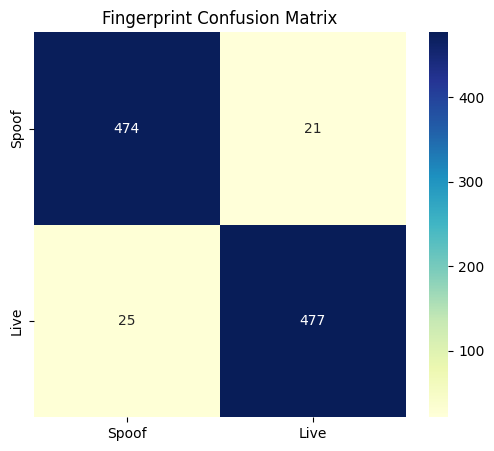

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap([[tn, fp],[fn, tp]],
            annot=True,
            fmt="d",
            cmap="YlGnBu",
            xticklabels=["Spoof","Live"],
            yticklabels=["Spoof","Live"])

plt.title("Fingerprint Confusion Matrix")
plt.show()

In [ ]:
import json, os

save_path = "/content/drive/MyDrive/Multimodal_Project/models"
os.makedirs(save_path, exist_ok=True)

model.save(save_path + "/fingerprint_model.keras")

with open(save_path + "/fingerprint_config.json","w") as f:
    json.dump({"threshold": float(best_thresh)}, f)

print("Saved successfully")

Saved successfully


In [ ]:
from tensorflow.keras.models import load_model

model = load_model(
    "/content/drive/MyDrive/Multimodal_Project/models/fingerprint_model.keras"
)

print("✅ Fingerprint model loaded")

✅ Fingerprint model loaded


In [ ]:
import json

with open("/content/drive/MyDrive/Multimodal_Project/models/fingerprint_config.json") as f:
    config = json.load(f)

threshold = config["threshold"]

print("Loaded threshold:", threshold)

In [ ]:
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)

    y_true.extend(labels.numpy())
    y_pred.extend(preds.flatten())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Predictions generated")

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 

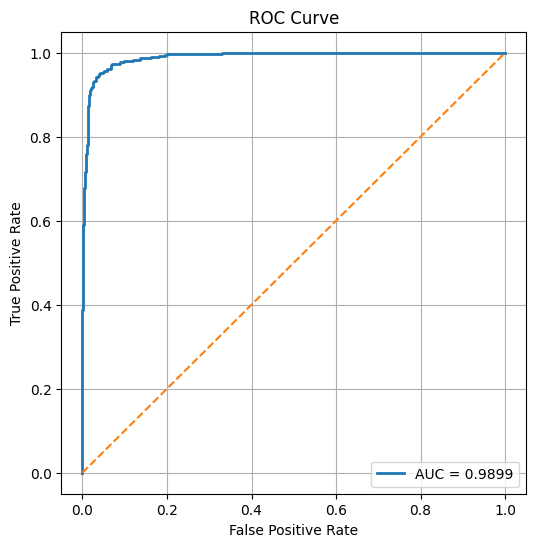

AUC Score: 0.989903014205803


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# ROC
fpr, tpr, thresholds = roc_curve(y_true, y_pred)

# AUC
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {roc_auc:.4f}"
)

# Random line
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend(loc="lower right")

plt.grid()

plt.show()

print("AUC Score:", roc_auc)

**FACE MODEL**

In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Multimodal_Project/raw_data/casia_fasd.zip"
extract_path = "/content/drive/MyDrive/Multimodal_Project/raw_data/casia_fasd"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ CASIA-FASD extracted")

✅ CASIA-FASD extracted


In [ ]:
for root, dirs, files in os.walk(extract_path):
    print(root, "→", len(files))

/content/drive/MyDrive/Multimodal_Project/raw_data/casia_fasd → 0
/content/drive/MyDrive/Multimodal_Project/raw_data/casia_fasd/test_img → 0
/content/drive/MyDrive/Multimodal_Project/raw_data/casia_fasd/test_img/test_img → 0
/content/drive/MyDrive/Multimodal_Project/raw_data/casia_fasd/test_img/test_img/color → 2408
/content/drive/MyDrive/Multimodal_Project/raw_data/casia_fasd/test_img/test_img/depth → 2408
/content/drive/MyDrive/Multimodal_Project/raw_data/casia_fasd/train_img → 0
/content/drive/MyDrive/Multimodal_Project/raw_data/casia_fasd/train_img/train_img → 0
/content/drive/MyDrive/Multimodal_Project/raw_data/casia_fasd/train_img/train_img/color → 1655
/content/drive/MyDrive/Multimodal_Project/raw_data/casia_fasd/train_img/train_img/depth → 1655


In [ ]:
import os, random, numpy as np
from collections import defaultdict

BASE = "/content/drive/MyDrive/Multimodal_Spoof_Project/datasets/casia_fasd"

train_dir = "/content/drive/MyDrive/Multimodal_Project/raw_data/casia_fasd/train_img/train_img/color"
test_dir  = "/content/drive/MyDrive/Multimodal_Project/raw_data/casia_fasd/test_img/test_img/color"

all_files = []

for d in [train_dir, test_dir]:
    for f in os.listdir(d):
        if f.endswith(".jpg"):
            all_files.append(os.path.join(d, f))

print("Total images:", len(all_files))

Total images: 4063


In [ ]:
def get_video_id(path):
    name = os.path.basename(path)
    parts = name.split("_")
    return parts[0] + "_" + parts[1]   # e.g., 10_1.avi

video_groups = defaultdict(list)

for f in all_files:
    vid = get_video_id(f)
    video_groups[vid].append(f)

print("Total videos:", len(video_groups))

Total videos: 270


In [ ]:
video_ids = list(video_groups.keys())
random.shuffle(video_ids)

split = int(0.8 * len(video_ids))

train_vids = video_ids[:split]
val_vids   = video_ids[split:]

train_files, val_files = [], []
train_labels, val_labels = [], []

def get_label(path):
    return 1 if "real" in path else 0

for vid in train_vids:
    for f in video_groups[vid]:
        train_files.append(f)
        train_labels.append(get_label(f))

for vid in val_vids:
    for f in video_groups[vid]:
        val_files.append(f)
        val_labels.append(get_label(f))

train_files = np.array(train_files)
val_files   = np.array(val_files)
train_labels = np.array(train_labels)
val_labels   = np.array(val_labels)

print("Train:", len(train_files), "Val:", len(val_files))

Train: 3066 Val: 997


In [ ]:
import tensorflow as tf

IMG_SIZE = 224
BATCH_SIZE = 32

def load_img(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0

    # mild enhancement
    img = tf.image.adjust_contrast(img, 1.3)

    return img, label

data_aug = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal")
])

train_ds = tf.data.Dataset.from_tensor_slices((train_files, train_labels))
train_ds = train_ds.map(load_img, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.map(lambda x,y: (data_aug(x), y))
train_ds = train_ds.shuffle(2000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_files, val_labels))
val_ds = val_ds.map(load_img, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(0.6639237765266349), 1: np.float64(2.0250990752972258)}


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)

x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)

x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.2)(x)

output = layers.Dense(1, activation="sigmoid")(x)

model_face = models.Model(inputs=base_model.input, outputs=output)

In [ ]:
model_face.compile(
    optimizer=tf.keras.optimizers.Adam(3e-4),
    loss=tf.keras.losses.BinaryFocalCrossentropy(),
    metrics=["accuracy"]
)

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=2),
    tf.keras.callbacks.ModelCheckpoint(
        "/content/drive/MyDrive/Multimodal_Spoof_Project/models/face_best.keras",
        save_best_only=True
    )
]

In [ ]:
history = model_face.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

Epoch 1/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 172s 1s/step - accuracy: 0.8056 - loss: 0.1276 - val_accuracy: 0.8736 - val_loss: 0.0702 - learning_rate: 3.0000e-04
Epoch 2/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - accuracy: 0.9201 - loss: 0.0459 - val_accuracy: 0.9097 - val_loss: 0.0535 - learning_rate: 3.0000e-04
Epoch 3/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.9517 - loss: 0.0298 - val_accuracy: 0.9157 - val_loss: 0.0576 - learning_rate: 3.0000e-04
Epoch 4/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.9693 - loss: 0.0207 - val_accuracy: 0.9308 - val_loss: 0.0466 - learning_rate: 3.0000e-04
Epoch 5/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 149s 1s/step - accuracy: 0.9781 - loss: 0.0164 - val_accuracy: 0.9248 - val_loss: 0.0621 - learning_rate: 3.0000e-04
Epoch 6/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.9830 - loss: 0.0111 - val_accuracy: 0.9348 - val_loss: 0.0588 - learning_rate: 3.0000e-04
Epoch 7/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 146s 1s/step - accuracy: 0.9853 

In [ ]:
from sklearn.metrics import confusion_matrix

y_true, y_pred = [], []

for images, labels in val_ds:
    preds = model_face.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(preds.flatten())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

threshold = 0.60
y_hat = (y_pred > threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_true, y_hat).ravel()

accuracy = (tp + tn) / (tp + tn + fp + fn)
FAR = fp / (fp + tn)
FRR = fn / (fn + tp)

print("Confusion Matrix:\n", [[tn, fp], [fn, tp]])
print(f"Accuracy: {accuracy:.4f}")
print(f"FAR: {FAR:.4f}")
print(f"FRR: {FRR:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 949ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 750ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 797ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 989ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 889ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 979ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 903ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 923ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 931ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 949ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 959ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 743ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 922ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 969ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 767ms/step
1/1 ━━━━━━━━━━━━━━━

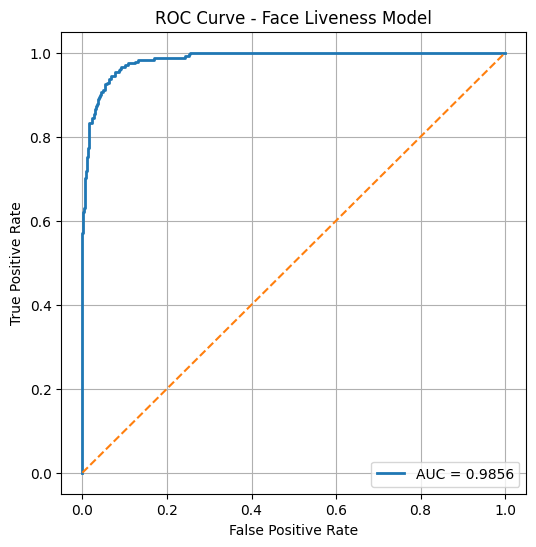

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Compute ROC
fpr, tpr, thresholds = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')  # random line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Face Liveness Model")
plt.legend(loc="lower right")

plt.grid()
plt.show()

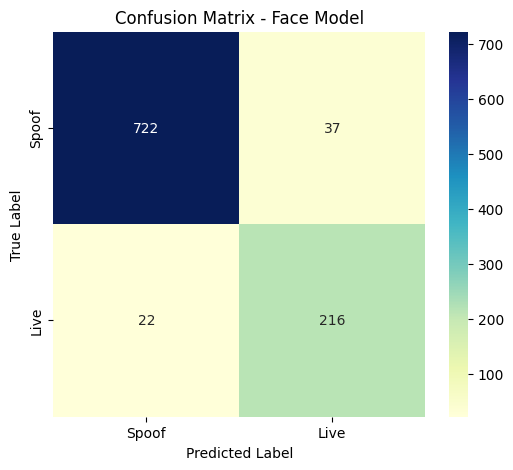

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_hat)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="YlGnBu",
            xticklabels=["Spoof", "Live"],
            yticklabels=["Spoof", "Live"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Face Model")

plt.show()

In [ ]:
model_face.save("/content/drive/MyDrive/Multimodal_Project/models/face_best.keras")

import json
with open("/content/drive/MyDrive/Multimodal_Project/models/face_config.json","w") as f:
    json.dump({"threshold": 0.60}, f)